In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")
data_dpt = pd.read_csv("csvs/departamento.csv")

In [7]:
data_dpt

,orcid,nome,departamento
0,orcid.org/0000-0002-4321-9075,Adín Ramírez Rivera,DSI
1,orcid.org/0000-0002-2914-5380,Alexandre Xavier Falcão,DSI
2,orcid.org/0000-0003-0750-0502,Alexandru Cristian Telea,Utrecht University
3,orcid.org/0000-0003-0683-7672,Anamaria Gomide,DTC
4,orcid.org/0000-0002-4236-8212,Anderson de Rezende Rocha,DSI
...,...,...,...
64,orcid.org/0000-0001-7434-2642,Santiago Valdés Ravelo,DTC
65,orcid.org/0000-0001-5685-8004,Siome Goldenstein,DSI
66,orcid.org/0000-0001-8923-0432,Tomasz Kowaltowski,DSC
67,orcid.org/0000-0001-5968-7108,Torsten Braun,Universität Bern


## Criação de nós

In [3]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [4]:
uni_key = {uni:key for key, uni in enumerate(data_filiacao["filiacao padronizada"].unique())}
css4_colors = list(mcolors.CSS4_COLORS.keys())

# You can use the first 130 of these colors
palette_130 = css4_colors[:data_filiacao["filiacao padronizada"].unique().shape[0]]

In [9]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        if data_dpt[data_dpt["orcid"]==url].shape[0] == 0:
            dpt = None
        else:
            dpt = data_dpt[data_dpt["orcid"]==url]["departamento"].values[0]
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]],
                            dpt=dpt
                            )
    n_banca -=- 1

In [10]:
# Exemplo de nó:
grafo_defesas.nodes["0000-0002-8803-0401"]

{'nome': 'Rodolfo Azevedo',
 'filiacao': 'Universidade Estadual de Campinas',
 'genero': 'Masculino',
 'filiacao_genero': 'Masculino_interno',
 'bipartite': 0,
 'marker': 'M',
 'cor_bin': 'red',
 'cor': 'aliceblue',
 'dpt': 'DSC'}

## Criação de arestas (arestas representam colaborações em defesas de mestrado, mestrado profissional ou doutorado)

In [11]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval][0]["weight"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

## Cálculos dos graus máximo e mínimo

In [134]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

max_degree = 0
for no, degree in grafo_defesas.degree():
    if degree > max_degree:
        max_degree = degree
max_degree_person = [no for no, degree in grafo_defesas.degree() if degree == max_degree]

In [135]:
print(f"Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)")
for person in max_degree_person_out:
    print(grafo_defesas.nodes[person], f"Qtd de orientações: {grafo_defesas.out_degree[person]}")

Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)
{'nome': 'Ricardo Torres', 'filiacao': 'Universidade Estadual de Campinas', 'genero': 'Masculino', 'filiacao_genero': 'Masculino_interno', 'bipartite': 0, 'marker': 'M', 'cor_bin': 'red', 'cor': 'aliceblue', 'dpt': 'DSI'} Qtd de orientações: 125


In [136]:
print(f"Pessoa(s) com maior quantidade de avaliações (maior grau de ENTRADA)")
for person in max_degree_person_in:
    print(grafo_defesas.nodes[person], f"Qtd de avaliações: {grafo_defesas.in_degree[person]}")

Pessoa(s) com maior quantidade de avaliações (maior grau de ENTRADA)
{'nome': 'Helio Pedrini', 'filiacao': 'Universidade Estadual de Campinas', 'genero': 'Masculino', 'filiacao_genero': 'Masculino_interno', 'bipartite': 0, 'marker': 'M', 'cor_bin': 'red', 'cor': 'aliceblue', 'dpt': 'DSI'} Qtd de avaliações: 69


In [137]:
print(f"Pessoa(s) com maior quantidade de colaborações (maior grau)")
for person in max_degree_person:
    print(grafo_defesas.nodes[person], f"Qtd de avaliações: {grafo_defesas.degree[person]}")

Pessoa(s) com maior quantidade de colaborações (maior grau)
{'nome': 'Helio Pedrini', 'filiacao': 'Universidade Estadual de Campinas', 'genero': 'Masculino', 'filiacao_genero': 'Masculino_interno', 'bipartite': 0, 'marker': 'M', 'cor_bin': 'red', 'cor': 'aliceblue', 'dpt': 'DSI'} Qtd de avaliações: 190


### Gráfico log-log com graus de saída (orientação->avaliação)

In [138]:
degree_sequence = [d for _, d in grafo_defesas.out_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)

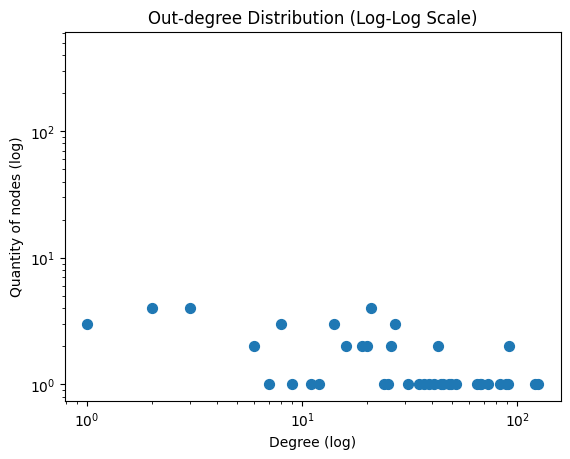

In [139]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Quantity of nodes (log)")
plt.title("Out-degree Distribution (Log-Log Scale)")
plt.show()

#### Separando por gênero

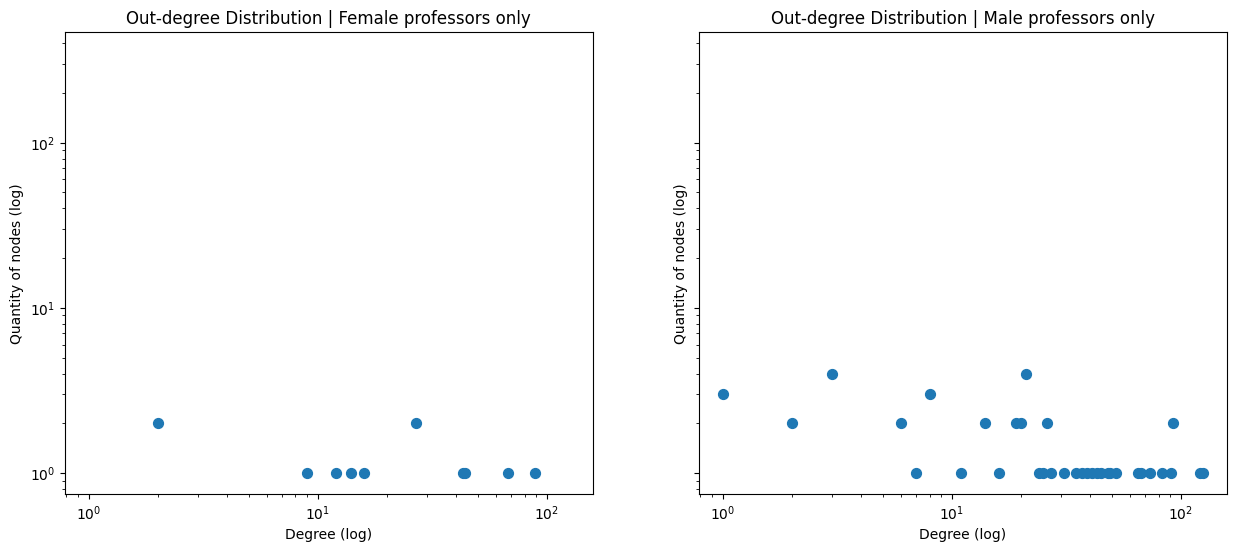

In [44]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True, sharey=True)

genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.out_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[0].scatter(deg, cnt, s=50, color="#1f78b4")

genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.out_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[1].scatter(deg, cnt, s=50, color="#1f78b4")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("Degree (log)")
ax[0].set_ylabel("Quantity of nodes (log)")
ax[0].set_title("Out-degree Distribution | Female professors only")
ax[1].set_xlabel("Degree (log)")
ax[1].set_ylabel("Quantity of nodes (log)")
ax[1].set_title("Out-degree Distribution | Male professors only")



plt.show()

### Gráfico log-log com graus de entrada (avaliação<-orientação)

In [45]:
degree_sequence = [d for _, d in grafo_defesas.in_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

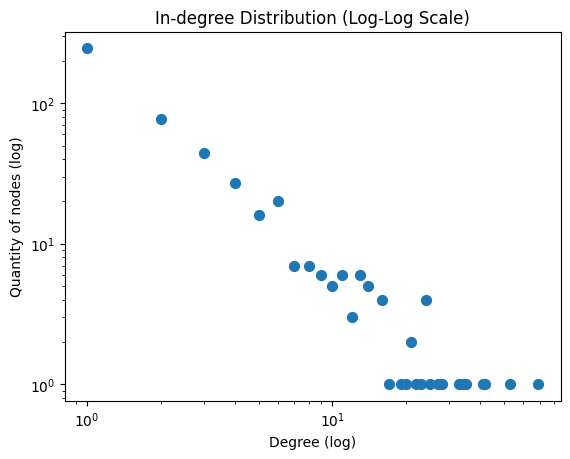

In [47]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Quantity of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

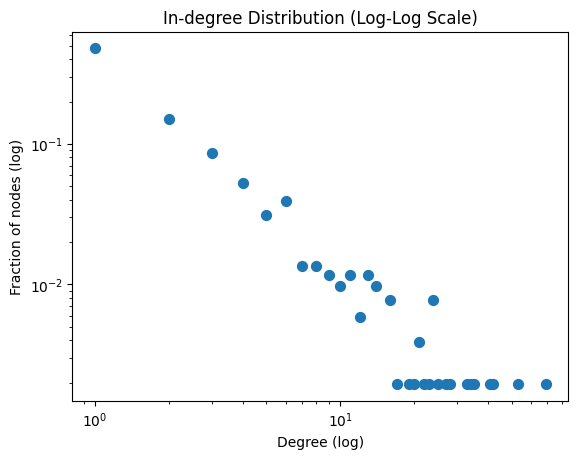

In [48]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

#### Separando por gênero

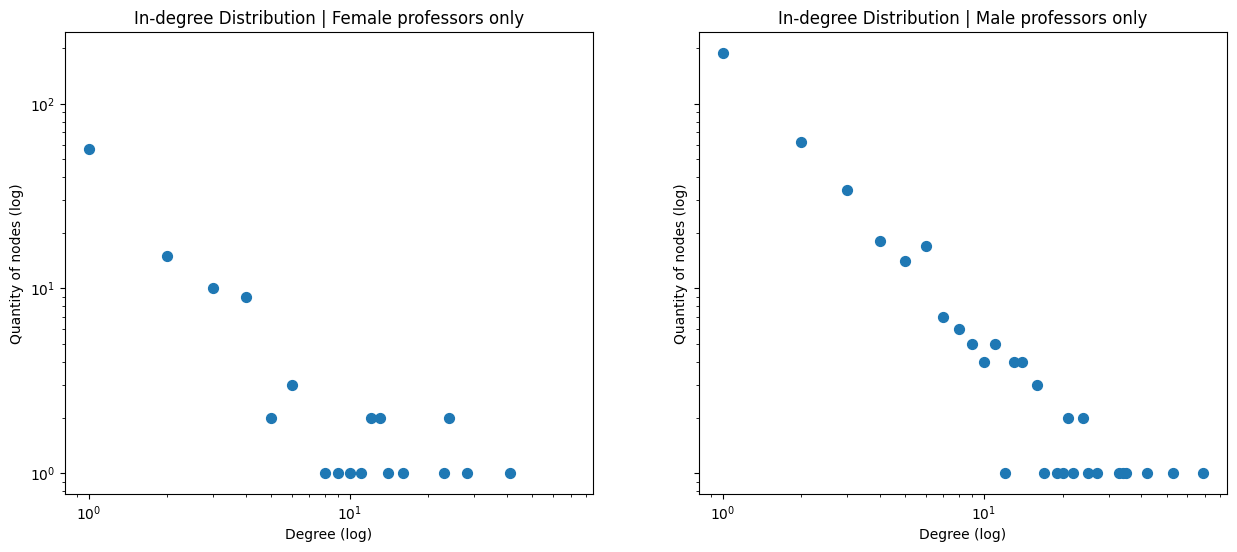

In [49]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True, sharey=True)

genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.in_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[0].scatter(deg, cnt, s=50, color="#1f78b4")

genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.in_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[1].scatter(deg, cnt, s=50, color="#1f78b4")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("Degree (log)")
ax[0].set_ylabel("Quantity of nodes (log)")
ax[0].set_title("In-degree Distribution | Female professors only")
ax[1].set_xlabel("Degree (log)")
ax[1].set_ylabel("Quantity of nodes (log)")
ax[1].set_title("In-degree Distribution | Male professors only")



plt.show()

## Matriz de correlação de graus

In [207]:
deg_corr_matrix = np.zeros(shape=(max_degree, max_degree))

for current_node in grafo_defesas.nodes:
    grau_current_node = grafo_defesas.degree[current_node]
    for adj_node in grafo_defesas[current_node]:
        grau_adj_node = grafo_defesas.degree[adj_node]
        deg_corr_matrix[grau_current_node-1, grau_adj_node-1] -=- 1
        deg_corr_matrix[grau_adj_node-1, grau_current_node-1] -=- 1
deg_corr_matrix /= len(grafo_defesas.edges)

<Axes: >

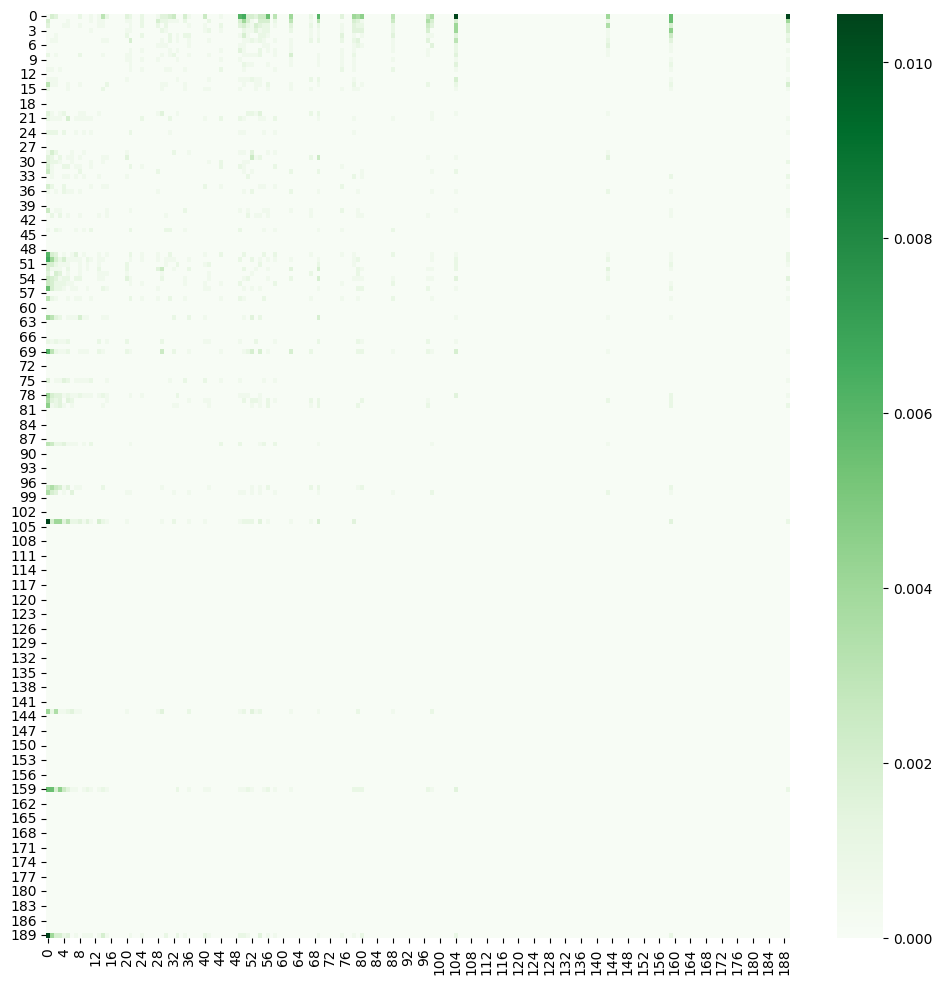

In [208]:
fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(deg_corr_matrix, cmap="Greens")

## Contagem de nós e links

In [50]:
print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas.nodes)}")

Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): 514


In [51]:
print(f"Quantidade de nós F: {len([node for node in grafo_defesas.nodes if grafo_defesas.nodes[node]['genero']=='Feminino'])}")

Quantidade de nós F: 114


In [52]:
print(f"Quantidade de nós F: {len([node for node in grafo_defesas.nodes if grafo_defesas.nodes[node]['genero']=='Masculino'])}")

Quantidade de nós F: 399


In [53]:
print(f"Quantidade de links (cada link representa uma colaboração entre professores em uma banca): {len(grafo_defesas.edges)}")

Quantidade de links (cada link representa uma colaboração entre professores em uma banca): 1989


## Grau médio

In [54]:
print(f"Grau médio dos nós: {np.array([d for _, d in grafo_defesas.degree()]).mean()} \u00B1 {np.array([d for _, d in grafo_defesas.degree()]).std()}")
print(f"Grau médio de saída: {np.array([d for _, d in grafo_defesas.out_degree()]).mean()} \u00B1 {np.array([d for _, d in grafo_defesas.out_degree()]).std()}")
print(f"Grau médio de entrada: {np.array([d for _, d in grafo_defesas.in_degree()]).mean()} \u00B1 {np.array([d for _, d in grafo_defesas.in_degree()]).std()}")

Grau médio dos nós: 7.739299610894942 ± 20.006860017466067
Grau médio de saída: 3.869649805447471 ± 14.821917369480712
Grau médio de entrada: 3.869649805447471 ± 6.635341431191931


In [55]:
print(f"<K^2>: {np.array([d**2 for _, d in grafo_defesas.degree()]).mean()} \u00B1 {np.array([d**2 for _, d in grafo_defesas.degree()]).std()}")

<K^2>: 460.1712062256809 ± 2474.0404266998626


## Robustez

In [56]:
k = np.array([d for _, d in grafo_defesas.degree()]).mean()
k2 = np.array([d ** 2 for _, d in grafo_defesas.degree()]).mean()
fc_ER = 1 - (1 / k)
fc = 1 - (1 / ((k2/k) - 1))
fc, fc_ER

(np.float64(0.9828940012900451), np.float64(0.8707893413775767))

### Por gênero

In [57]:
genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
graus = np.array([d for pessoa, d in grafo_defesas.degree() if pessoa in grafo_defesas_genero])
graus_saida = np.array([d for pessoa, d in grafo_defesas.out_degree() if pessoa in grafo_defesas_genero])
graus_entrada = np.array([d for pessoa, d in grafo_defesas.in_degree() if pessoa in grafo_defesas_genero])
print(f"{genero}:")
print(f"Grau médio dos nós: {graus.mean()} \u00B1 {graus.std()}")
print(f"Grau médio de saída: {graus_saida.mean()} \u00B1 {graus_saida.std()}")
print(f"Grau médio de entrada: {graus_entrada.mean()} \u00B1 {graus_entrada.std()}")

Feminino:
Grau médio dos nós: 6.947368421052632 ± 16.273346039472223
Grau médio de saída: 3.0964912280701755 ± 12.347291270704165
Grau médio de entrada: 3.8508771929824563 ± 6.218580613336742


In [58]:
genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
graus = np.array([d for pessoa, d in grafo_defesas.degree() if pessoa in grafo_defesas_genero])
graus_saida = np.array([d for pessoa, d in grafo_defesas.out_degree() if pessoa in grafo_defesas_genero])
graus_entrada = np.array([d for pessoa, d in grafo_defesas.in_degree() if pessoa in grafo_defesas_genero])
print(f"{genero}:")
print(f"Grau médio dos nós: {graus.mean()} \u00B1 {graus.std()}")
print(f"Grau médio de saída: {graus_saida.mean()} \u00B1 {graus_saida.std()}")
print(f"Grau médio de entrada: {graus_entrada.mean()} \u00B1 {graus_entrada.std()}")

Masculino:
Grau médio dos nós: 7.982456140350878 ± 20.96726636042545
Grau médio de saída: 4.1002506265664165 ± 15.465702208414
Grau médio de entrada: 3.882205513784461 ± 6.756313979852888


## Coeficiente de Assortatividade

In [66]:
nx.degree_assortativity_coefficient(grafo_defesas)

0.00661068525058013

In [69]:
nx.degree_assortativity_coefficient(grafo_defesas,
                                    nodes=[node for node in grafo_defesas.nodes \
                                                            if grafo_defesas.nodes[node]["genero"] == "Feminino"])

0.07475194926392668

In [70]:
nx.degree_assortativity_coefficient(grafo_defesas,
                                    nodes=[node for node in grafo_defesas.nodes \
                                                            if grafo_defesas.nodes[node]["genero"] == "Masculino"])

-0.019771827409550958

## Colaborações

In [12]:
adj_matrix = nx.adjacency_matrix(grafo_defesas)
colabs = pd.DataFrame(data=adj_matrix,
             columns=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())],
                    index=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())])

In [13]:
colabs_uni = np.where(colabs != 0, 1, 0)
colabs_uni = pd.DataFrame(data=colabs_uni,
             columns=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())],
                    index=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())])

In [14]:
for orcid1 in list(grafo_defesas.nodes.keys()):
    nome1 = grafo_defesas.nodes[orcid1]["nome"]
    for orcid2 in list(grafo_defesas.nodes.keys()):
        if orcid2 == orcid1: continue
        nome2 = grafo_defesas.nodes[orcid2]["nome"]
        if colabs_uni.at[nome1, nome2] == 1:
            colabs_uni.at[nome2, nome1] = 1

In [15]:
nodes_unicamp_orcid = []

for edge in grafo_defesas.out_edges:
    nodes_unicamp_orcid.append(edge[0])
nodes_unicamp_orcid = set(nodes_unicamp_orcid)

In [16]:
nodes_unicamp = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if node in nodes_unicamp_orcid]

In [64]:
len(nodes_unicamp)

63

In [65]:
colabs.loc[nodes_unicamp, nodes_unicamp].values.max()

np.int64(26)

In [17]:
nodes_unicamp_fem = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and 
                                                                                           grafo_defesas.nodes[node]["genero"] == "Feminino")]
nodes_unicamp_masc = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and 
                                                                                           grafo_defesas.nodes[node]["genero"] == "Masculino")]

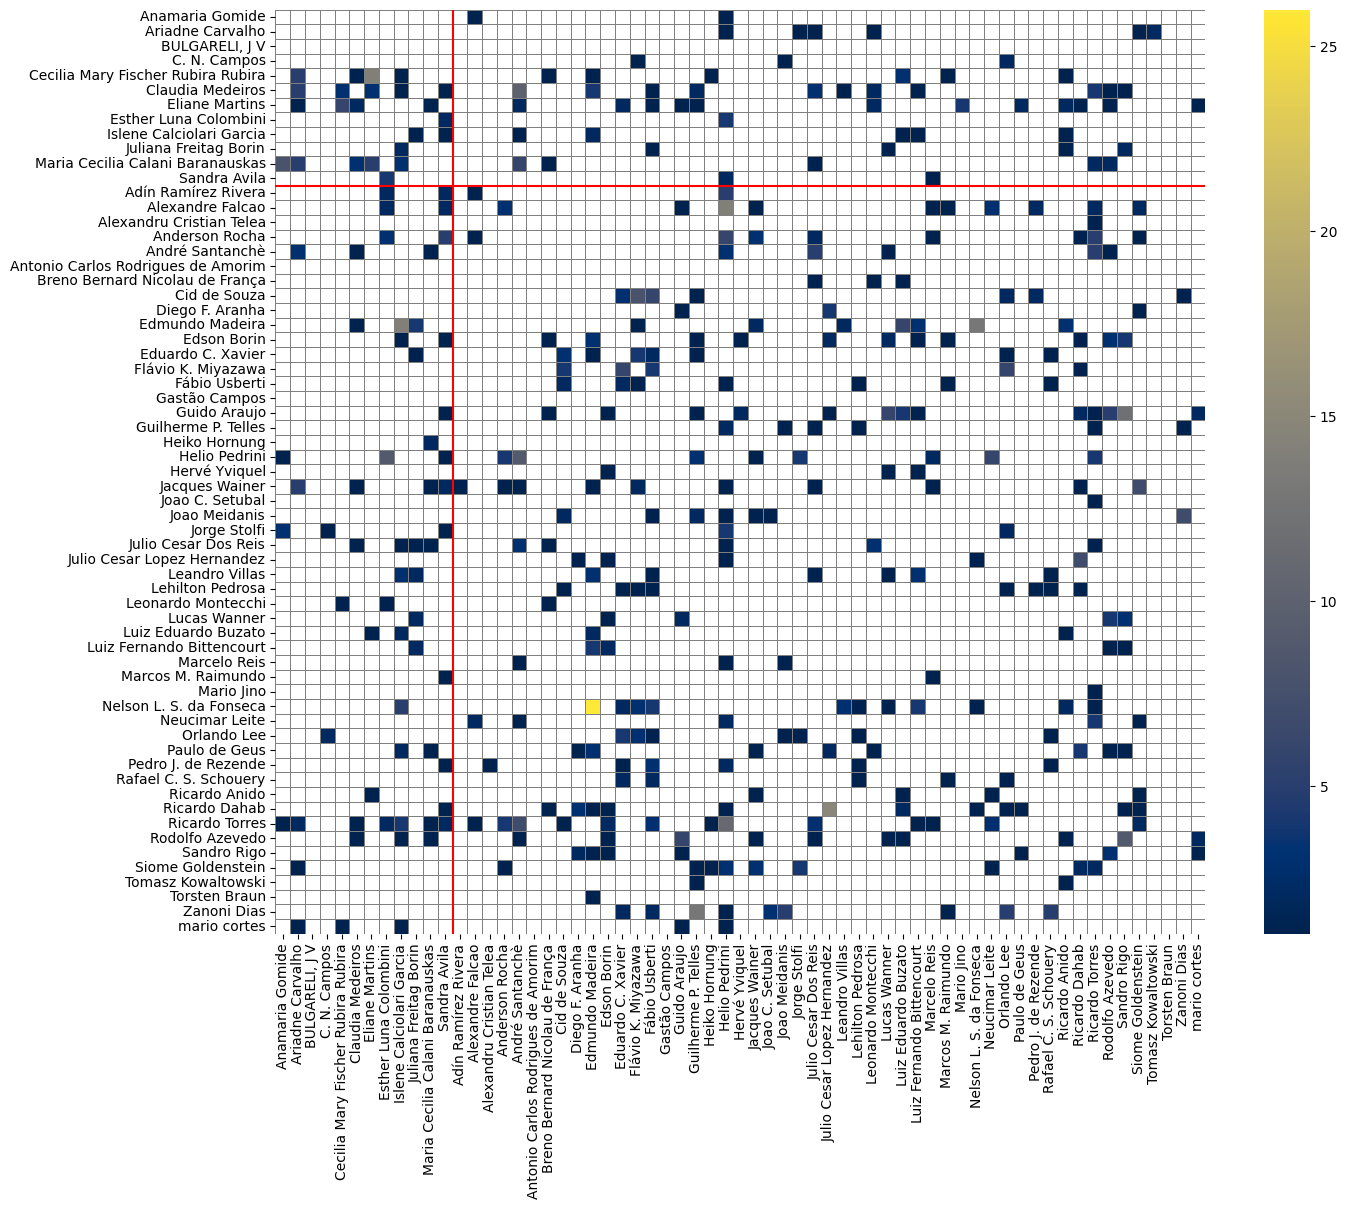

In [18]:
fig, ax = plt.subplots(figsize=(15,12))
mask = colabs.loc[sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc), sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc)] == 0
sns.heatmap(colabs.loc[sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc), sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc)],
            cmap="cividis", linewidths=.5, mask=mask, linecolor="gray")

ax.hlines(len(nodes_unicamp_fem), *ax.get_xlim(), colors="red")
ax.vlines(len(nodes_unicamp_fem), *ax.get_ylim(), colors="red")

In [72]:
for edge in grafo_defesas.edges(data=True):
    if edge[0] == edge[1]:
        print(edge, edge[2])

('0000-0003-2046-602X', '0000-0003-2046-602X', {'ano': 2023, 'tipo': 'DOUTORADO'}) {'ano': 2023, 'tipo': 'DOUTORADO'}


In [70]:
edge

('0000-0002-8803-0401', '0000-0002-9539-6874', 0)

In [19]:
row_colors = ["gold"] * len(nodes_unicamp_fem) + ["maroon"] * len(nodes_unicamp_masc)

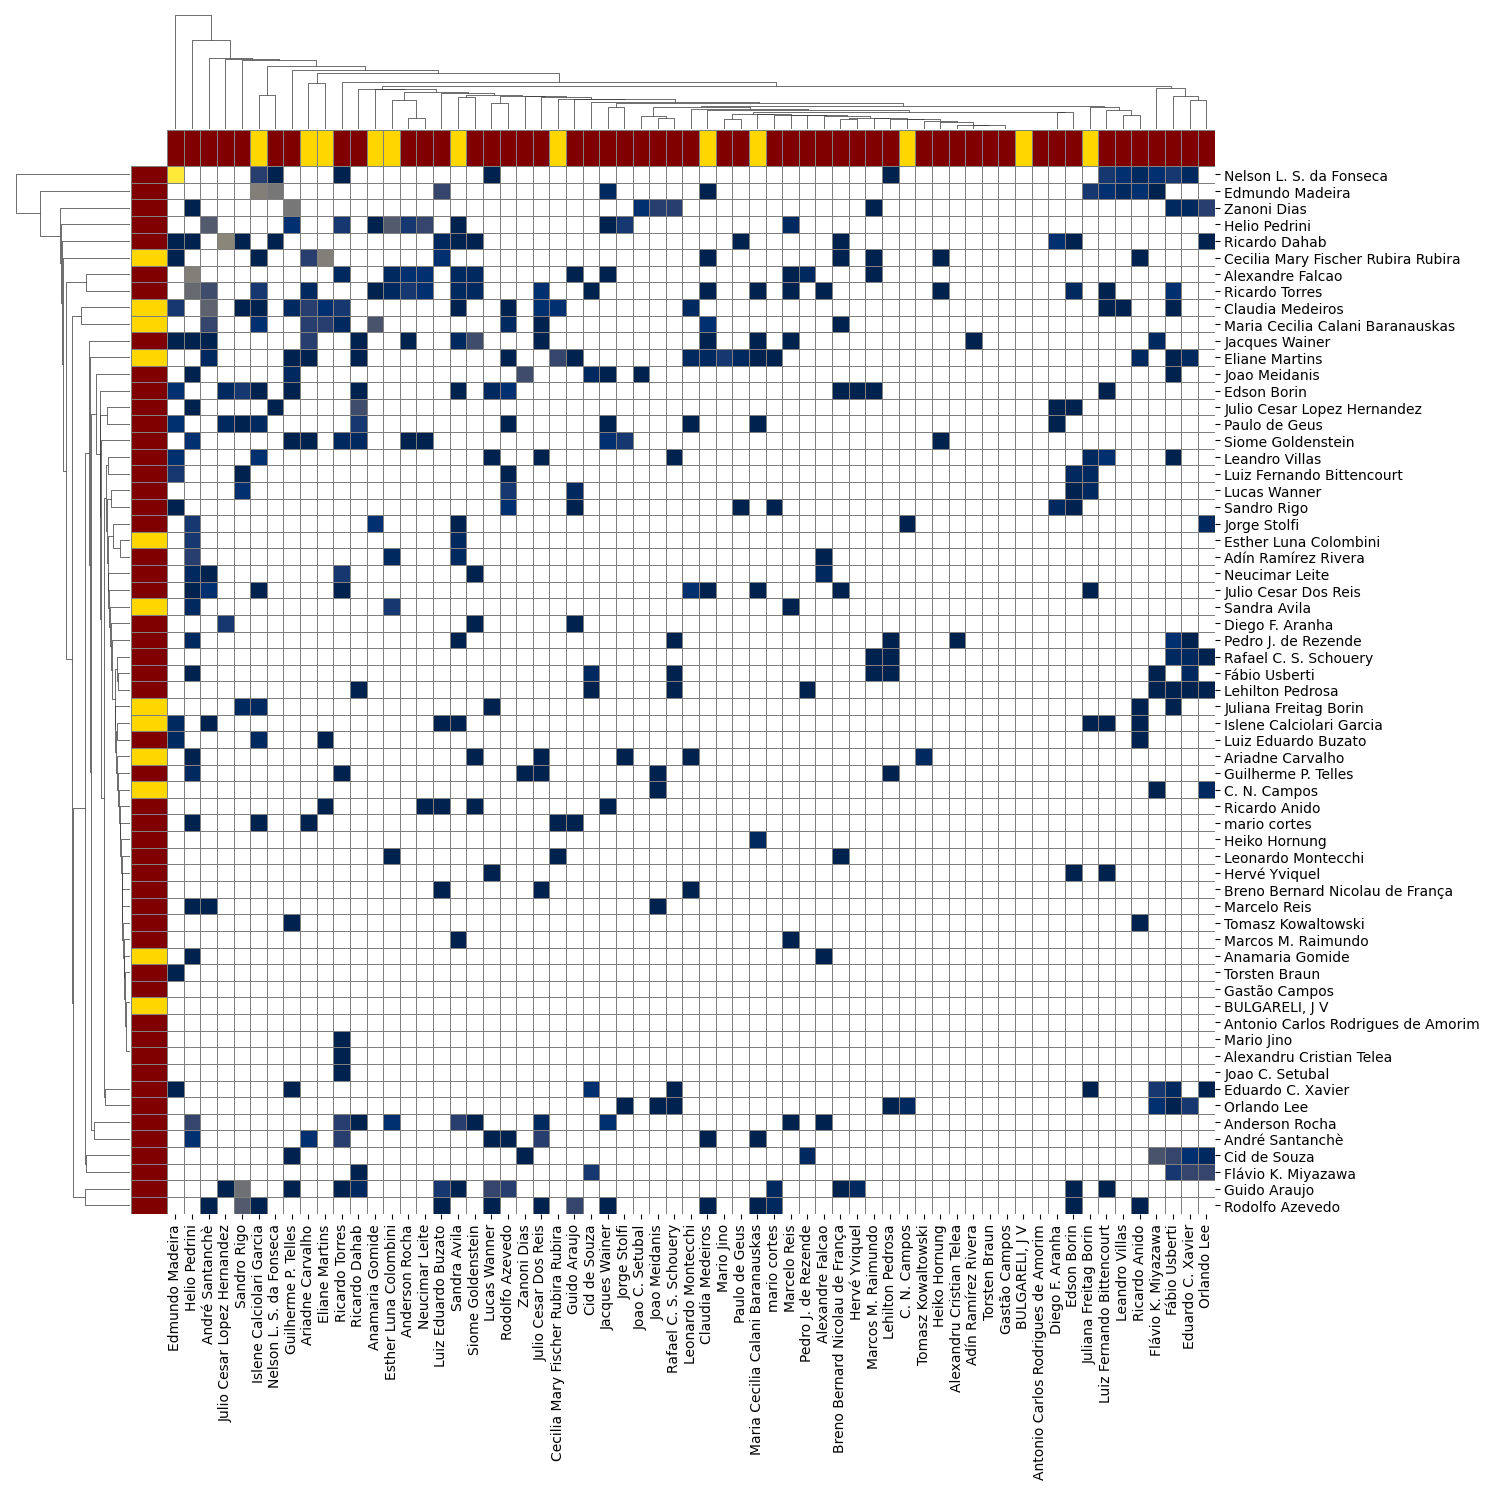

In [20]:
# fig, ax = plt.subplots(figsize=(15,12))
mask = colabs.loc[sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc), sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc)] == 0
sns.clustermap(colabs.loc[sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc), sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc)],
            cmap="cividis", linewidths=.5, mask=mask, linecolor="gray", figsize=(15,15),
            method="average", row_colors=row_colors, col_colors=row_colors,
            xticklabels=sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc),
            yticklabels=sorted(nodes_unicamp_fem)+sorted(nodes_unicamp_masc),
            cbar_pos=None, dendrogram_ratio=.1
            )

In [87]:
data_dpt["dpt"].unique()

array(['DSI', 'Utrecht University', 'DTC', 'Labjor', 'FOP', 'DSC', 'FCM',
       'FEEC', 'Universität Bern'], dtype=object)

In [35]:
nodes_unicamp_dpt = {}
for dpt in data_dpt["departamento"].unique():
    nodes_unicamp_dpt[dpt] = [(grafo_defesas.nodes[node]["nome"], grafo_defesas.nodes[node]["genero"])
                                for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and grafo_defesas.nodes[node]["dpt"] == dpt)]
    # nodes_unicamp_dpt[dpt+"F"] = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and 
    #                                                                                        grafo_defesas.nodes[node]["dpt"] == dpt and
    #                                                                                        grafo_defesas.nodes[node]["genero"] == "Feminino")]
    # nodes_unicamp_dpt[dpt+"M"] = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and 
    #                                                                                        grafo_defesas.nodes[node]["dpt"] == dpt and
    #                                                                                        grafo_defesas.nodes[node]["genero"] == "Masculino")]

In [52]:
nodes_unicamp_dpt

{'DSI': [('Neucimar Leite', 'Masculino'),
  ('Luiz Eduardo Buzato', 'Masculino'),
  ('André Santanchè', 'Masculino'),
  ('Cecilia Mary Fischer Rubira Rubira', 'Feminino'),
  ('Eliane Martins', 'Feminino'),
  ('Ariadne Carvalho', 'Feminino'),
  ('Jacques Wainer', 'Masculino'),
  ('Helio Pedrini', 'Masculino'),
  ('Anderson Rocha', 'Masculino'),
  ('Ricardo Torres', 'Masculino'),
  ('Siome Goldenstein', 'Masculino'),
  ('Heiko Hornung', 'Masculino'),
  ('Julio Cesar Dos Reis', 'Masculino'),
  ('Esther Luna Colombini', 'Feminino'),
  ('Sandra Avila', 'Feminino'),
  ('Maria Cecilia Calani Baranauskas', 'Feminino'),
  ('Leonardo Montecchi', 'Masculino'),
  ('Breno Bernard Nicolau de França', 'Masculino'),
  ('Alexandre Falcao', 'Masculino'),
  ('Marcos M. Raimundo', 'Masculino'),
  ('Marcelo Reis', 'Masculino'),
  ('Claudia Medeiros', 'Feminino'),
  ('Adín Ramírez Rivera', 'Masculino')],
 'Utrecht University': [('Alexandru Cristian Telea', 'Masculino')],
 'DTC': [('Guilherme P. Telles', 'Ma

In [66]:
row_colors_dpt = []
row_color_gender = []
nodes_unicamp_dpt_list = []
for i, dpt in enumerate(data_dpt["departamento"].unique()):
    row_colors_dpt += [sns.color_palette("tab10")[i]] * len(nodes_unicamp_dpt[dpt])
    # nodes_unicamp_dpt_list += nodes_unicamp_dpt[dpt][0]
    # for k, v in nodes_unicamp_dpt.items():
    for person, gender in nodes_unicamp_dpt[dpt]:
        nodes_unicamp_dpt_list.append(person)
        row_color_gender.append("maroon" if gender == "Masculino" else "gold")
            # print(person)
    # for genero in 

In [61]:
len(set(nodes_unicamp_dpt_list))

63

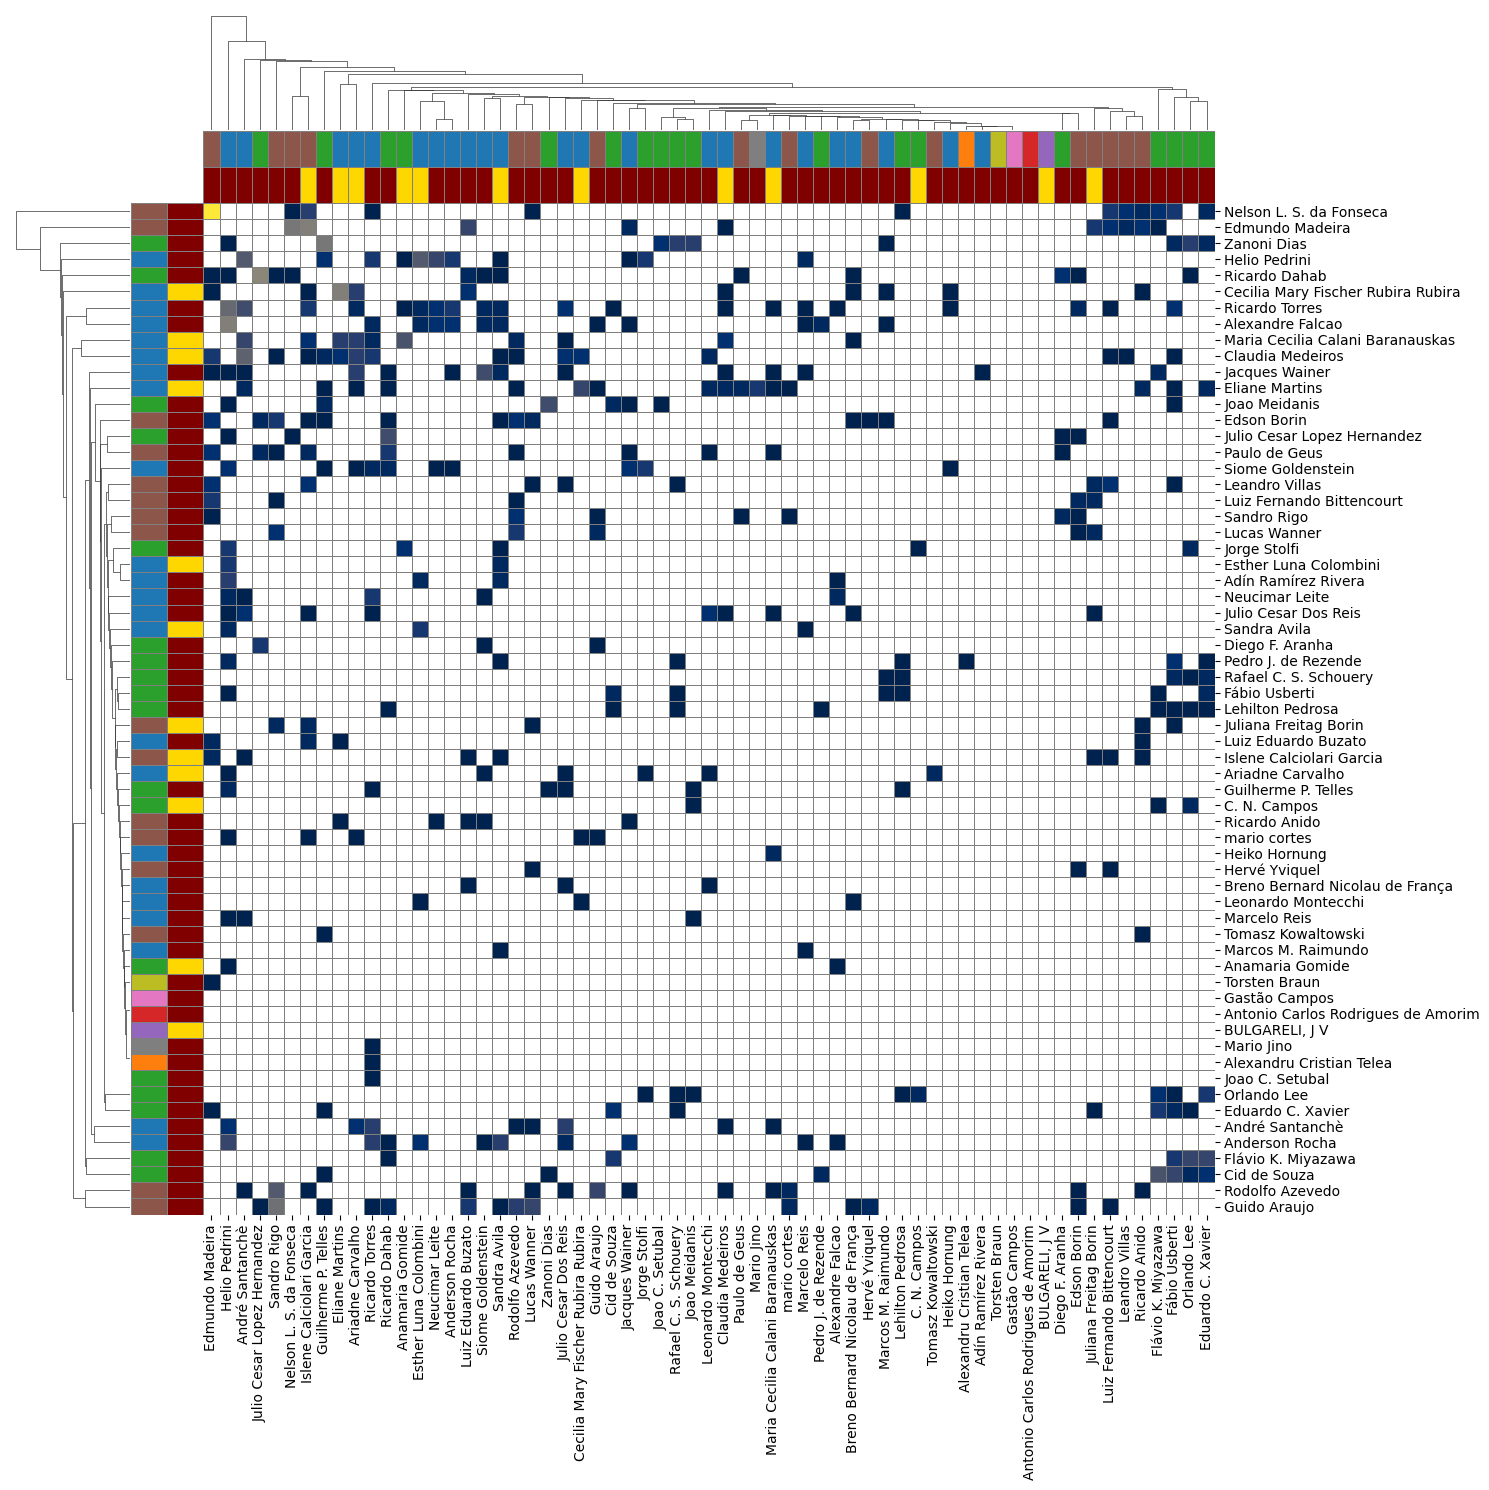

In [68]:
# fig, ax = plt.subplots(figsize=(15,12))
mask = colabs.loc[(nodes_unicamp_dpt_list), (nodes_unicamp_dpt_list)] == 0
sns.clustermap(colabs.loc[(nodes_unicamp_dpt_list), (nodes_unicamp_dpt_list)],
            cmap="cividis", linewidths=.5, mask=mask, linecolor="gray", figsize=(15,15),
            method="average", row_colors=[row_colors_dpt, row_color_gender], col_colors=[row_colors_dpt, row_color_gender],
            xticklabels=(nodes_unicamp_dpt_list),
            yticklabels=(nodes_unicamp_dpt_list),
            cbar_pos=None, dendrogram_ratio=.1
            )

In [33]:
nodes_notunicamp_fem = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node not in nodes_unicamp_orcid and 
                                                                                           grafo_defesas.nodes[node]["genero"] == "Feminino")]
nodes_notunicamp_masc = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node not in nodes_unicamp_orcid and 
                                                                                           grafo_defesas.nodes[node]["genero"] == "Masculino")]

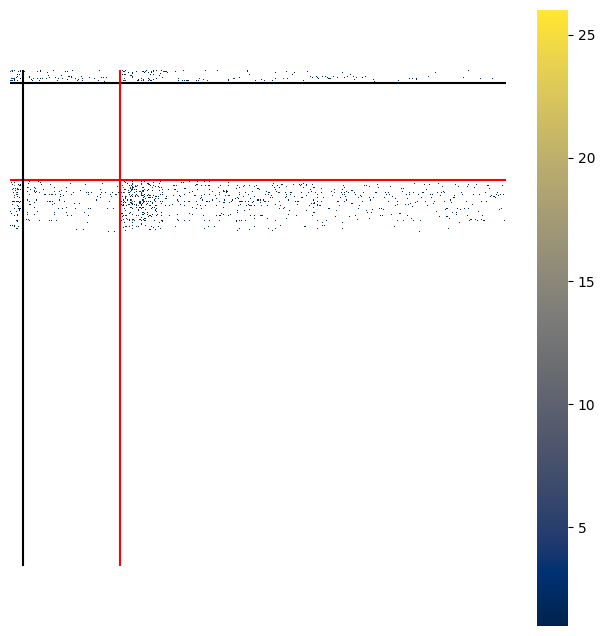

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
mask = colabs.loc[nodes_unicamp_fem+nodes_notunicamp_fem+nodes_unicamp_masc+nodes_notunicamp_masc,
                  nodes_unicamp_fem+nodes_notunicamp_fem+nodes_unicamp_masc+nodes_notunicamp_masc] == 0
g=sns.heatmap(colabs.loc[nodes_unicamp_fem+nodes_notunicamp_fem+nodes_unicamp_masc+nodes_notunicamp_masc,
                       nodes_unicamp_fem+nodes_notunicamp_fem+nodes_unicamp_masc+nodes_notunicamp_masc],
            cmap="cividis", linewidths=.0, mask=mask, linecolor="gray", square=True)

ax.hlines(len(nodes_unicamp_fem), *ax.get_xlim(), colors="black")
ax.hlines(len(nodes_unicamp_fem+nodes_notunicamp_fem), *ax.get_xlim(), colors="red")
ax.vlines(len(nodes_unicamp_fem), *ax.get_ylim(), colors="black")
ax.vlines(len(nodes_unicamp_fem+nodes_notunicamp_fem), *ax.get_ylim(), colors="red")
ax.set(xlabel=None, xticklabels=[], yticklabels=[])
ax.tick_params(left=False, bottom=False, right=False) ## other options are right and top


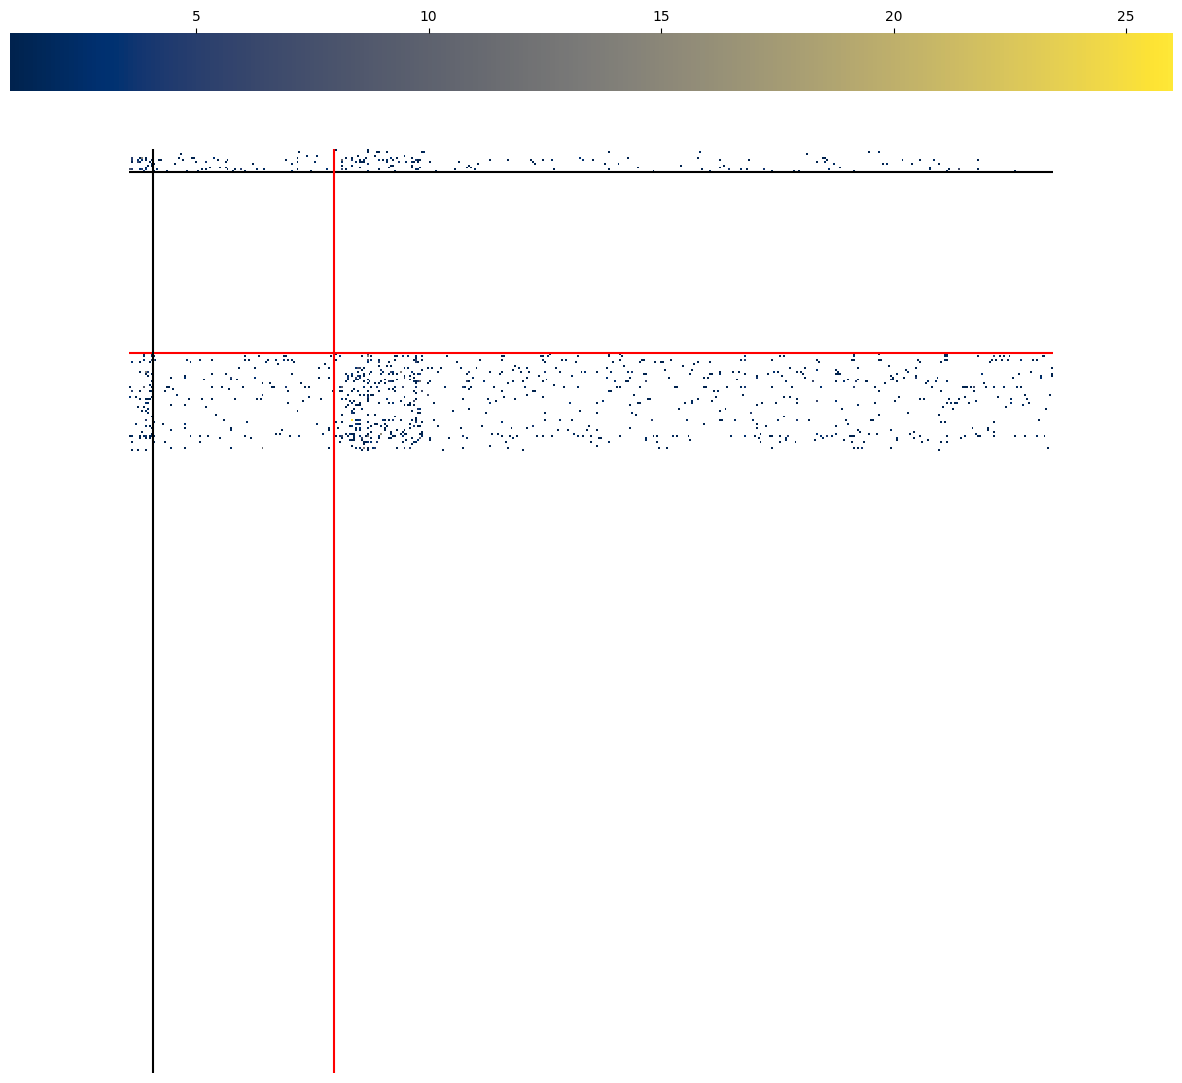

In [80]:
fig, ax = plt.subplots(figsize=(15,15))
mask = colabs.loc[sorted(nodes_unicamp_fem)+sorted(nodes_notunicamp_fem)+sorted(nodes_unicamp_masc)+sorted(nodes_notunicamp_masc),
                  sorted(nodes_unicamp_fem)+sorted(nodes_notunicamp_fem)+sorted(nodes_unicamp_masc)+sorted(nodes_notunicamp_masc)] == 0
g=sns.heatmap(colabs.loc[sorted(nodes_unicamp_fem)+sorted(nodes_notunicamp_fem)+sorted(nodes_unicamp_masc)+sorted(nodes_notunicamp_masc),
                       sorted(nodes_unicamp_fem)+sorted(nodes_notunicamp_fem)+sorted(nodes_unicamp_masc)+sorted(nodes_notunicamp_masc)],
            cmap="cividis", linewidths=.0, mask=mask, linecolor="gray", square=True,
            cbar_kws = dict(location="top"))

ax.hlines(len(nodes_unicamp_fem), *ax.get_xlim(), colors="black")
ax.hlines(len(nodes_unicamp_fem+nodes_notunicamp_fem), *ax.get_xlim(), colors="red")
ax.vlines(len(nodes_unicamp_fem), *ax.get_ylim(), colors="black")
ax.vlines(len(nodes_unicamp_fem+nodes_notunicamp_fem), *ax.get_ylim(), colors="red")
ax.set(xlabel=None, xticklabels=[], yticklabels=[])
ax.tick_params(left=False, bottom=False, right=False) ## other options are right and top


In [229]:
colabs_dict = nx.to_dict_of_dicts(grafo_defesas)
conta_colabs = []
dupla_colabs = []
for pessoa1, _ in colabs_dict.items():
    for pessoa2 in colabs_dict[pessoa1]:
        conta_colabs.append(len(colabs_dict[pessoa1][pessoa2]))
        dupla_colabs.append((pessoa1, pessoa2))

In [230]:
top_n = 10
for i in range(1, top_n+1):
    # i==
    idx_colab = np.argsort(conta_colabs)[-i]
    # print(idx_colab)
    pessoa1 = grafo_defesas.nodes[dupla_colabs[idx_colab][0]]["nome"]
    pessoa2 = grafo_defesas.nodes[dupla_colabs[idx_colab][1]]["nome"]
    qtd = conta_colabs[idx_colab]
    print(f"Colaboração entre {pessoa1} e {pessoa2} com {qtd}")

Colaboração entre Nelson L. S. da Fonseca e Edmundo Madeira com 26
Colaboração entre Ricardo Dahab e Julio Cesar Lopez Hernandez com 15
Colaboração entre Alexandre Falcao e Helio Pedrini com 14
Colaboração entre Cecilia Mary Fischer Rubira Rubira e Eliane Martins com 14
Colaboração entre Edmundo Madeira e Islene Calciolari Garcia com 14
Colaboração entre Zanoni Dias e Guilherme P. Telles com 13
Colaboração entre Edmundo Madeira e Nelson L. S. da Fonseca com 13
Colaboração entre Guido Araujo e Sandro Rigo com 12
Colaboração entre Ricardo Torres e Helio Pedrini com 11
Colaboração entre Zanoni Dias e Maria Emilia Walter com 11
